# AI Resume Screening & Skill Matching System

This project builds an AI-based system to evaluate resumes against job descriptions using NLP techniques.  
It performs skill matching, semantic similarity analysis, resume ranking, and provides explainable insights.

## Problem Statement

Recruiters often receive a large number of resumes for a single job role.  
Manually screening each resume is time-consuming and inefficient.

This project aims to automate resume screening by:
- Matching skills between resume and job description
- Calculating similarity scores
- Ranking candidates
- Providing insights such as strengths and gaps

In [ ]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 1: Input Data

We start by defining:
- A sample job description
- A sample resume text

These act as initial inputs to test the system.

In [ ]:
job_description = """
We are looking for a Data Science Intern with strong knowledge of Python,
machine learning, and data analysis. The candidate should have experience
with pandas, numpy, scikit-learn, and basic NLP techniques.
Knowledge of SQL and data visualization is a plus.
"""

In [ ]:
resume_text = """
I am a Data Science student with hands-on experience in Python and machine learning.
I have worked on data cleaning, exploratory data analysis, and built models using
scikit-learn. I am comfortable working with pandas and numpy.
I have basic knowledge of NLP and experience using Jupyter Notebook and GitHub.
"""

In [ ]:
print("JOB DESCRIPTION:\n")
print(job_description)

print("\n" + "="*70 + "\n")

print("RESUME:\n")
print(resume_text)

JOB DESCRIPTION:


We are looking for a Data Science Intern with strong knowledge of Python,
machine learning, and data analysis. The candidate should have experience
with pandas, numpy, scikit-learn, and basic NLP techniques.
Knowledge of SQL and data visualization is a plus.



RESUME:


I am a Data Science student with hands-on experience in Python and machine learning.
I have worked on data cleaning, exploratory data analysis, and built models using
scikit-learn. I am comfortable working with pandas and numpy.
I have basic knowledge of NLP and experience using Jupyter Notebook and GitHub.



## Step 2: Text Preprocessing

Before analysis, we clean the text using:
- Lowercasing
- Removing punctuation
- Removing extra spaces

This ensures consistency and improves model performance.

In [ ]:
def clean_text(text):

    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
clean_job_description = clean_text(job_description)
clean_resume = clean_text(resume_text)

print("Clean Job Description:\n")
print(clean_job_description)

print("\n" + "="*50 + "\n")

print("Clean Resume:\n")
print(clean_resume)

Clean Job Description:

we are looking for a data science intern with strong knowledge of python machine learning and data analysis the candidate should have experience with pandas numpy scikitlearn and basic nlp techniques knowledge of sql and data visualization is a plus


Clean Resume:

i am a data science student with handson experience in python and machine learning i have worked on data cleaning exploratory data analysis and built models using scikitlearn i am comfortable working with pandas and numpy i have basic knowledge of nlp and experience using jupyter notebook and github


In [ ]:
skills_list = [
    "python",
    "machine learning",
    "data analysis",
    "pandas",
    "numpy",
    "scikit learn",
    "nlp",
    "sql",
    "data visualization"
]

## Step 3: Skill Extraction

We extract important skills from both:
- Job description
- Resume

This is done using a predefined list of skills.

The goal is to identify:
- Skills present in the job
- Skills present in the resume

In [ ]:
def extract_skills(text, skills):

    found_skills = []

    for skill in skills:
        if skill in text:
            found_skills.append(skill)

    return found_skills

In [ ]:
job_skills = extract_skills(clean_job_description, skills_list)
resume_skills = extract_skills(clean_resume, skills_list)

print("Skills Required for Job:")
print(job_skills)

print("\nSkills Found in Resume:")
print(resume_skills)

Skills Required for Job:
['python', 'machine learning', 'data analysis', 'pandas', 'numpy', 'nlp', 'sql', 'data visualization']

Skills Found in Resume:
['python', 'machine learning', 'data analysis', 'pandas', 'numpy', 'nlp']


## Step 4: Skill Matching

We compare job skills and resume skills to find:
- Matched Skills
- Missing Skills

We also compute a basic match score based on skill overlap.

In [ ]:
matched_skills = list(set(job_skills) & set(resume_skills))

print("Matched Skills:")
print(matched_skills)

Matched Skills:
['pandas', 'nlp', 'numpy', 'machine learning', 'python', 'data analysis']


In [ ]:
missing_skills = list(set(job_skills) - set(resume_skills))

print("Missing Skills:")
print(missing_skills)

Missing Skills:
['data visualization', 'sql']


In [ ]:
match_score = (len(matched_skills) / len(job_skills)) * 100

print("Match Score: ", round(match_score,2), "%")

Match Score:  75.0 %


In [ ]:
print("------ AI Resume Screening Result ------\n")

print("Matched Skills:")
print(matched_skills)

print("\nMissing Skills:")
print(missing_skills)

print("\nResume Match Score:")
print(round(match_score,2), "%")

------ AI Resume Screening Result ------

Matched Skills:
['pandas', 'nlp', 'numpy', 'machine learning', 'python', 'data analysis']

Missing Skills:
['data visualization', 'sql']

Resume Match Score:
75.0 %


## Step 5: Semantic Similarity using TF-IDF

We use TF-IDF (Term Frequency - Inverse Document Frequency) to:
- Convert text into numerical vectors

Then we use cosine similarity to:
- Measure similarity between resume and job description

This helps capture meaning beyond exact keyword matching.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english')

text_data = [clean_job_description, clean_resume]

tfidf_matrix = vectorizer.fit_transform(text_data)

In [ ]:
similarity_score = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])

print("Semantic Similarity Score:")
print(similarity_score)

Semantic Similarity Score:
[[0.48889281]]


In [ ]:
semantic_match = similarity_score[0][0] * 100

print("Semantic Match Score:", round(semantic_match,2), "%")

Semantic Match Score: 48.89 %


## Step 6: Resume Ranking System

We extend the system to handle multiple resumes.

Each resume is:
- Compared with the job description
- Assigned a similarity score

Resumes are then ranked from highest to lowest score.

In [ ]:
resumes = [
"""
Data science student skilled in Python, pandas, numpy, and machine learning.
Built ML models using scikit-learn and performed exploratory data analysis.
Basic knowledge of NLP and data visualization.
""",

"""
Software developer with strong skills in Java, Spring Boot, and backend systems.
Experience with databases and API development.
""",

"""
Aspiring data analyst with experience in SQL, Python, pandas, and data visualization.
Worked on data cleaning and statistical analysis projects.
"""
]

In [ ]:
clean_resumes = [clean_text(resume) for resume in resumes]

In [ ]:
scores = []

for resume in clean_resumes:

    text_data = [clean_job_description, resume]

    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(text_data)

    similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]

    scores.append(similarity * 100)

In [ ]:
ranking = list(enumerate(scores, start=1))

ranking.sort(key=lambda x: x[1], reverse=True)

In [ ]:
print("------ Resume Ranking System ------\n")

for rank, (resume_id, score) in enumerate(ranking, start=1):
    print(f"{rank}. Resume {resume_id} → {round(score,2)}% match")

------ Resume Ranking System ------

1. Resume 1 → 54.73% match
2. Resume 3 → 42.11% match
3. Resume 2 → 21.1% match


In [ ]:
resume_ids = [f"Resume {i+1}" for i in range(len(scores))]

## Step 7: Visualization

We visualize resume scores using a bar chart.

This helps:
- Compare candidates easily
- Present results in a clear and interpretable way

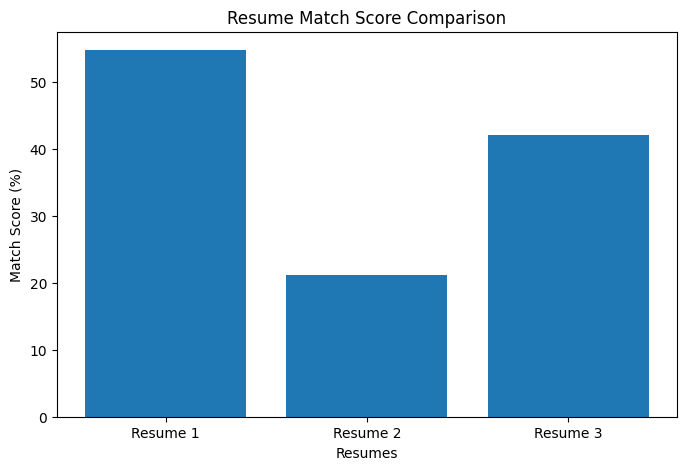

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(resume_ids, scores)

plt.xlabel("Resumes")
plt.ylabel("Match Score (%)")
plt.title("Resume Match Score Comparison")

plt.show()

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english')

text_data = [clean_job_description, clean_resume]

tfidf_matrix = vectorizer.fit_transform(text_data)

In [ ]:
feature_names = vectorizer.get_feature_names_out()

In [ ]:
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names,
    index=["Job Description", "Resume"]
)

In [ ]:
common_words = []

for word in feature_names:
    if tfidf_df.loc["Job Description", word] > 0 and tfidf_df.loc["Resume", word] > 0:
        common_words.append(word)

## Step 8: Explainable AI (Keyword Insights)

We extract top matching keywords between:
- Resume
- Job description

This helps explain:
- Why a resume matched
- Which terms contributed to similarity

In [ ]:
print("Top Matching Keywords:")
print(common_words[:10])

Top Matching Keywords:
['analysis', 'basic', 'data', 'experience', 'knowledge', 'learning', 'machine', 'nlp', 'numpy', 'pandas']


## Step 9: PDF Resume Input

We extend the system to work with real resumes.

Using a PDF parsing library:
- Upload a resume file
- Extract text from PDF
- Process it through the pipeline

This makes the system more practical and real-world ready.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ShreeKiran_DataScience_Intern.pdf to ShreeKiran_DataScience_Intern.pdf


In [ ]:
!pip install PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.2 MB/s eta 0:00:00


In [ ]:
import PyPDF2

pdf_file = list(uploaded.keys())[0]

with open(pdf_file, "rb") as file:
    reader = PyPDF2.PdfReader(file)

    resume_text = ""

    for page in reader.pages:
        resume_text += page.extract_text()

print(resume_text[:500])

SkillsSummaryData Scientist Intern | AI / ML
Bangalore, India
+91 9110495712 | srshreekiran2002@gmail.com
LinkedIn : linkedin.com/in/shree-kiran-ab0a96244 | GitHub : github.com/kiran08012002
Data Scientist Intern with hands-on experience in Python, machine learning, NLP, and computer vision. Skilled in data
preprocessing, EDA, feature engineering, and model evaluation on real-world datasets. Worked on research-driven NLP
projects, computer vision models, and analytics workflows. Aspiring to cont


In [ ]:
clean_uploaded_resume = clean_text(resume_text)

print(clean_uploaded_resume[:500])

skillssummarydata scientist intern ai ml bangalore india srshreekirangmailcom linkedin linkedincominshreekiranaba github githubcomkiran data scientist intern with handson experience in python machine learning nlp and computer vision skilled in data preprocessing eda feature engineering and model evaluation on realworld datasets worked on researchdriven nlp projects computer vision models and analytics workflows aspiring to contribute as a data scientist ai engineer to apply data driven problemso


In [ ]:
vectorizer = TfidfVectorizer(stop_words='english')

text_data = [clean_job_description, clean_uploaded_resume]

tfidf_matrix = vectorizer.fit_transform(text_data)

similarity_score = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]

final_score = similarity_score * 100

print("Resume Match Score:", round(final_score,2), "%")

Resume Match Score: 33.17 %


In [ ]:
uploaded_resume_skills = extract_skills(clean_uploaded_resume, skills_list)

print("Skills Found in Uploaded Resume:")
print(uploaded_resume_skills)

Skills Found in Uploaded Resume:
['python', 'machine learning', 'pandas', 'numpy', 'nlp', 'sql']


In [ ]:
matched_skills = list(set(job_skills) & set(uploaded_resume_skills))
missing_skills = list(set(job_skills) - set(uploaded_resume_skills))

print("\nMatched Skills:")
print(matched_skills)

print("\nMissing Skills:")
print(missing_skills)


Matched Skills:
['pandas', 'nlp', 'sql', 'numpy', 'machine learning', 'python']

Missing Skills:
['data analysis', 'data visualization']


## Step 10: Final Output & Insights

The system generates:
- Match Score
- Matched Skills
- Missing Skills
- Candidate Evaluation Summary

This provides actionable insights for recruiters.

In [ ]:
print("------ AI Resume Screening (PDF) ------\n")

print("Match Score:", round(final_score,2), "%")

print("\nMatched Skills:")
print(matched_skills)

print("\nMissing Skills:")
print(missing_skills)

------ AI Resume Screening (PDF) ------

Match Score: 33.17 %

Matched Skills:
['pandas', 'nlp', 'sql', 'numpy', 'machine learning', 'python']

Missing Skills:
['data analysis', 'data visualization']


In [ ]:
def generate_insights(matched_skills, missing_skills, score):

    print("------ Candidate Evaluation Summary ------\n")

    print(f"Match Score: {round(score,2)}%\n")

    # Strengths
    print("Strengths:")
    if matched_skills:
        for skill in matched_skills:
            print(f"- Strong in {skill}")
    else:
        print("- No strong matching skills found")

    # Gaps
    print("\nGaps:")
    if missing_skills:
        for skill in missing_skills:
            print(f"- Missing {skill}")
    else:
        print("- No major skill gaps")

    # Recommendation
    print("\nRecommendation:")
    if score >= 70:
        print("✅ Strong Fit")
    elif score >= 40:
        print("⚠️ Moderate Fit (Needs Improvement)")
    else:
        print("❌ Low Fit")

In [ ]:
generate_insights(matched_skills, missing_skills, final_score)

------ Candidate Evaluation Summary ------

Match Score: 33.17%

Strengths:
- Strong in pandas
- Strong in nlp
- Strong in sql
- Strong in numpy
- Strong in machine learning
- Strong in python

Gaps:
- Missing data analysis
- Missing data visualization

Recommendation:
❌ Low Fit


## Conclusion

This project demonstrates how NLP techniques can be used to automate resume screening.

Key features:
- Skill matching
- Semantic similarity using TF-IDF
- Resume ranking
- PDF resume processing
- Explainable insights

The system can be further improved using advanced NLP models and real-world datasets.